# HeritageNet — Results Dashboard · **PHASE 2 (fine-tuned)**

The fine-tuned model (`best_phase2.pt`): training curves · confusion matrix ·
misclassified images with model confidence + focus filter.

This is the **"after"** snapshot — compare against your phase-1 dashboard.
Pre-configured for phase 2; no settings to change.

> Run top to bottom: **Restart & Run All**.

In [1]:
# --- working directory: hop to repo root if launched from notebooks/ ---
import os
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("working dir:", os.getcwd())

import json
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

from heritagenet.data.datamodule import HeritageDataModule
from heritagenet.models.factory import build_model
from heritagenet.utils.device import get_device

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

# ------------------------------------------------------------- CONFIG (phase 2)
CKPT     = 'checkpoints/best_phase2.pt'          # the fine-tuned model
HISTORY  = 'outputs/history_phase2.json'         # phase-2 training curves
MODEL    = 'mobilenet_v3_small'
FOCUS    = None   # e.g. 'Narmadeshwor_Shiva_Temple' to isolate one site; None = all
# ------------------------------------------------------------------------------

device = get_device()
print('device:', device)

working dir: d:\pratik\HeritageNet\HeritageNet
device: cuda


## Load the fine-tuned model and the test data

In [2]:
dm = HeritageDataModule(root='data', batch_size=32).setup()
classes = dm.classes
print(f'{dm.num_classes} classes, {len(dm.test_dataset)} test images')

model = build_model(MODEL, num_classes=dm.num_classes,
                    pretrained=False, freeze_backbone=False)
ckpt = torch.load(CKPT, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.to(device).eval()
print('checkpoint:', CKPT, '| epoch', ckpt.get('epoch'), '| val_acc', ckpt.get('val_acc'))

26 classes, 179 test images
checkpoint: checkpoints/best_phase2.pt | epoch 7 | val_acc 0.8344827586206897


## 1 · Training curves (phase 2)

Fine-tuning continues from the phase-1 weights, so train accuracy starts high and
climbs to ~1.0 — watch the train/val gap widen (expected overfitting from unfreezing
1.5M params on limited data). The dashed line marks the best epoch that was restored.

curves from: outputs/history_phase2.json (current run)


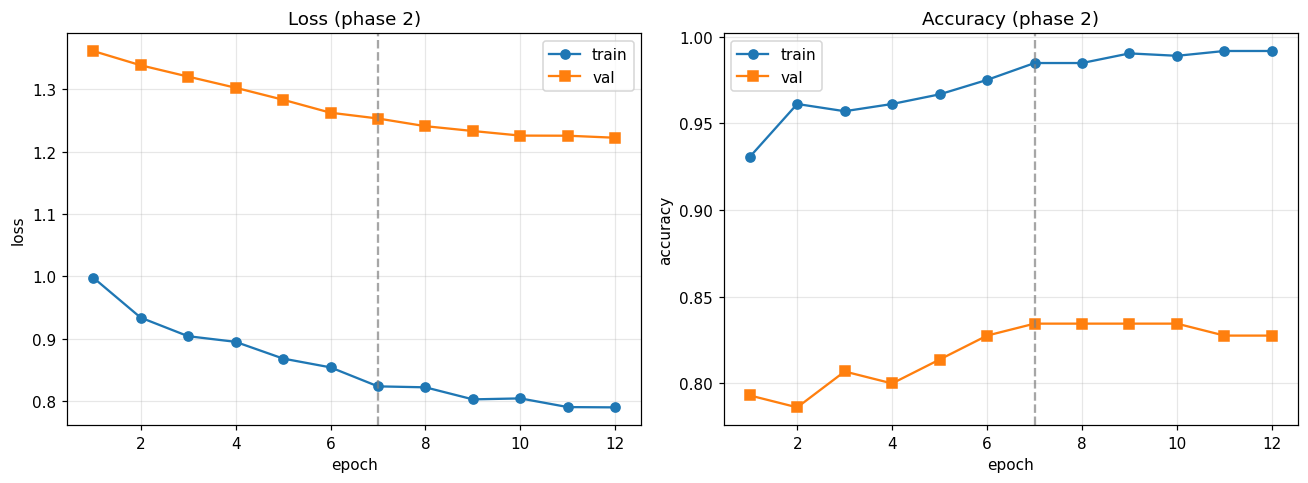

In [3]:
hist_path = Path(HISTORY)
if hist_path.exists():
    H = json.loads(hist_path.read_text()); src = HISTORY + ' (current run)'
else:
    # fallback: values from the phase-2 fine-tuning run
    H = {
      'train_loss':[0.436,0.282,0.197,0.159,0.112,0.093,0.060,0.056,0.045,0.037,
                    0.023,0.025,0.024,0.015,0.015,0.019,0.013],
      'train_acc' :[0.942,0.951,0.965,0.975,0.989,0.982,0.994,0.997,0.996,1.000,
                    1.000,0.997,0.997,1.000,1.000,0.999,1.000],
      'val_loss'  :[0.856,0.785,0.762,0.744,0.733,0.699,0.678,0.691,0.670,0.668,
                    0.666,0.665,0.666,0.660,0.664,0.667,0.665],
      'val_acc'   :[0.786,0.807,0.814,0.814,0.834,0.841,0.841,0.834,0.841,0.855,
                    0.862,0.876,0.862,0.862,0.862,0.869,0.869],
      'best_epoch':12,
    }
    src = 'embedded phase-2 fallback'
print('curves from:', src)

ep = range(1, len(H['train_loss']) + 1); best = H.get('best_epoch')
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(ep, H['train_loss'], 'o-', label='train'); a1.plot(ep, H['val_loss'], 's-', label='val')
a1.set_title('Loss (phase 2)'); a1.set_xlabel('epoch'); a1.set_ylabel('loss'); a1.legend(); a1.grid(alpha=.3)
a2.plot(ep, H['train_acc'], 'o-', label='train'); a2.plot(ep, H['val_acc'], 's-', label='val')
a2.set_title('Accuracy (phase 2)'); a2.set_xlabel('epoch'); a2.set_ylabel('accuracy'); a2.legend(); a2.grid(alpha=.3)
if best:
    for a in (a1, a2): a.axvline(best, ls='--', c='gray', alpha=.7)
plt.tight_layout(); plt.show()

## 2 · Test predictions, metrics, confusion matrix

In [4]:
loader = DataLoader(dm.test_dataset, batch_size=32, shuffle=False, num_workers=0)
y_true, y_pred, pred_conf, true_conf = [], [], [], []
with torch.no_grad():
    for imgs, lbls in loader:
        probs = F.softmax(model(imgs.to(device)), dim=1).cpu()
        p = probs.argmax(1)
        y_pred.extend(p.tolist()); y_true.extend(lbls.tolist())
        pred_conf.extend(probs.max(1).values.tolist())
        true_conf.extend(probs[range(len(lbls)), lbls].tolist())
y_true = np.array(y_true); y_pred = np.array(y_pred)
pred_conf = np.array(pred_conf); true_conf = np.array(true_conf)

acc = accuracy_score(y_true, y_pred); mf1 = f1_score(y_true, y_pred, average='macro')
print(f'PHASE 2 -> test accuracy: {acc:.3f}   macro-F1: {mf1:.3f}')
print('(phase-1 baseline was: accuracy 0.799   macro-F1 0.784)\n')
print(classification_report(y_true, y_pred, target_names=classes, digits=3, zero_division=0))

PHASE 2 -> test accuracy: 0.816   macro-F1: 0.796
(phase-1 baseline was: accuracy 0.799   macro-F1 0.784)

                                       precision    recall  f1-score   support

                  Ashok_stupa_Chaitya      1.000     1.000     1.000         8
                     Badrinath_Temple      0.800     0.800     0.800         5
                     Balkumari_Temple      1.000     1.000     1.000         5
                      Bhagwati_Temple      1.000     0.800     0.889         5
            Bhairahawa_Hanuman_Temple      1.000     1.000     1.000         5
            Bijayanagar_Gadesh_Mandir      1.000     0.400     0.571         5
                        Chamundra_Mai      0.750     0.429     0.545         7
                  Ganesh_Mandir_Patan      0.857     1.000     0.923         6
                           Heritage_1      1.000     0.800     0.889         5
                           Heritage_2      1.000     0.600     0.750        10
                       

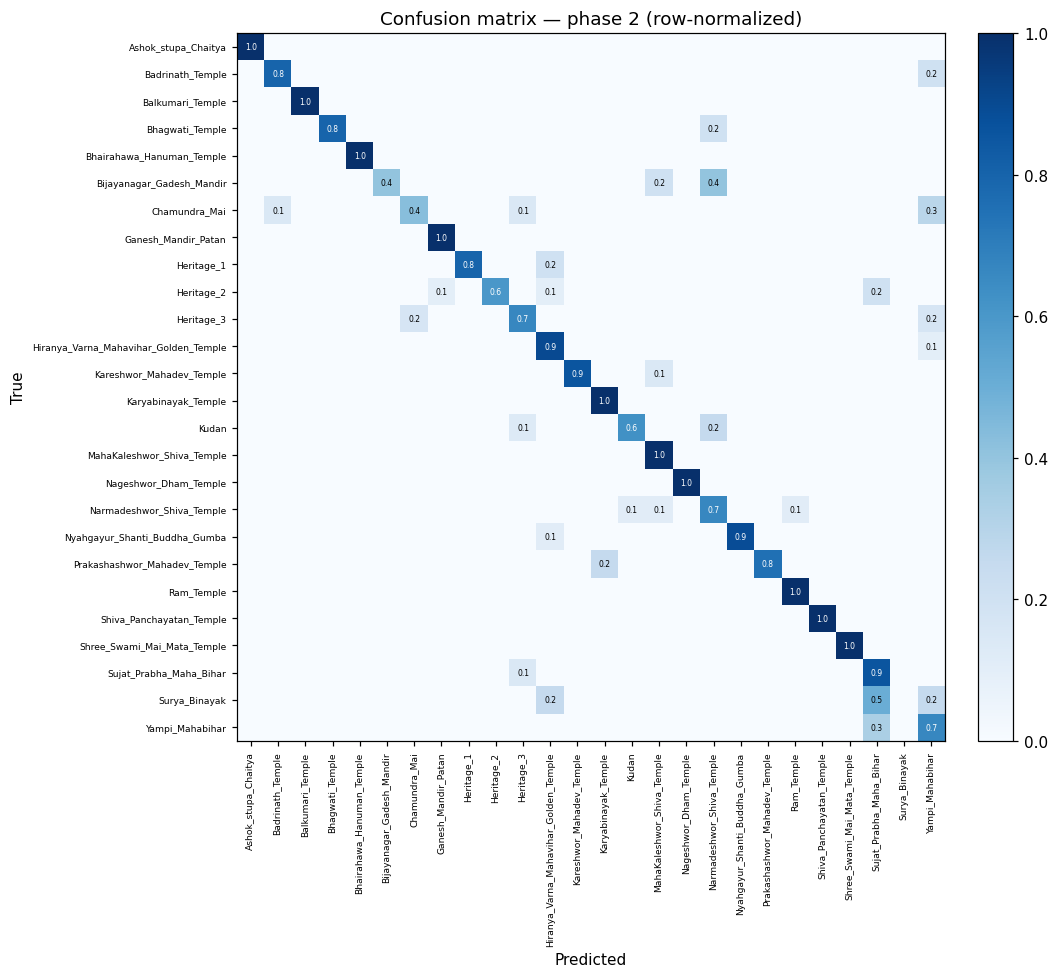

In [5]:
cm = confusion_matrix(y_true, y_pred, labels=range(dm.num_classes))
cmn = np.nan_to_num(cm / cm.sum(axis=1, keepdims=True))
n = dm.num_classes
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(classes, rotation=90, fontsize=6)
ax.set_yticklabels(classes, fontsize=6)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('Confusion matrix — phase 2 (row-normalized)')
for i in range(n):
    for j in range(n):
        if cmn[i, j] > 0:
            ax.text(j, i, f'{cmn[i,j]:.1f}', ha='center', va='center',
                    fontsize=5, color='white' if cmn[i,j] > .5 else 'black')
fig.colorbar(im, fraction=0.046, pad=0.04); plt.tight_layout(); plt.show()

## 3 · Misclassified images — with confidence + focus filter

Each wrong photo shows **TRUE** (real site, and the probability the model gave it) and
**PRED** (its wrong guess + confidence). Sorted most-confident-first; dark red = confidently wrong.

Set `FOCUS` in the config cell (e.g. `'Narmadeshwor_Shiva_Temple'` or `'Surya_Binayak'`)
and re-run this cell to isolate one site.

33 misclassified images (ALL classes)
  of these, 1 are HIGH-confidence (>70%) — inspect first


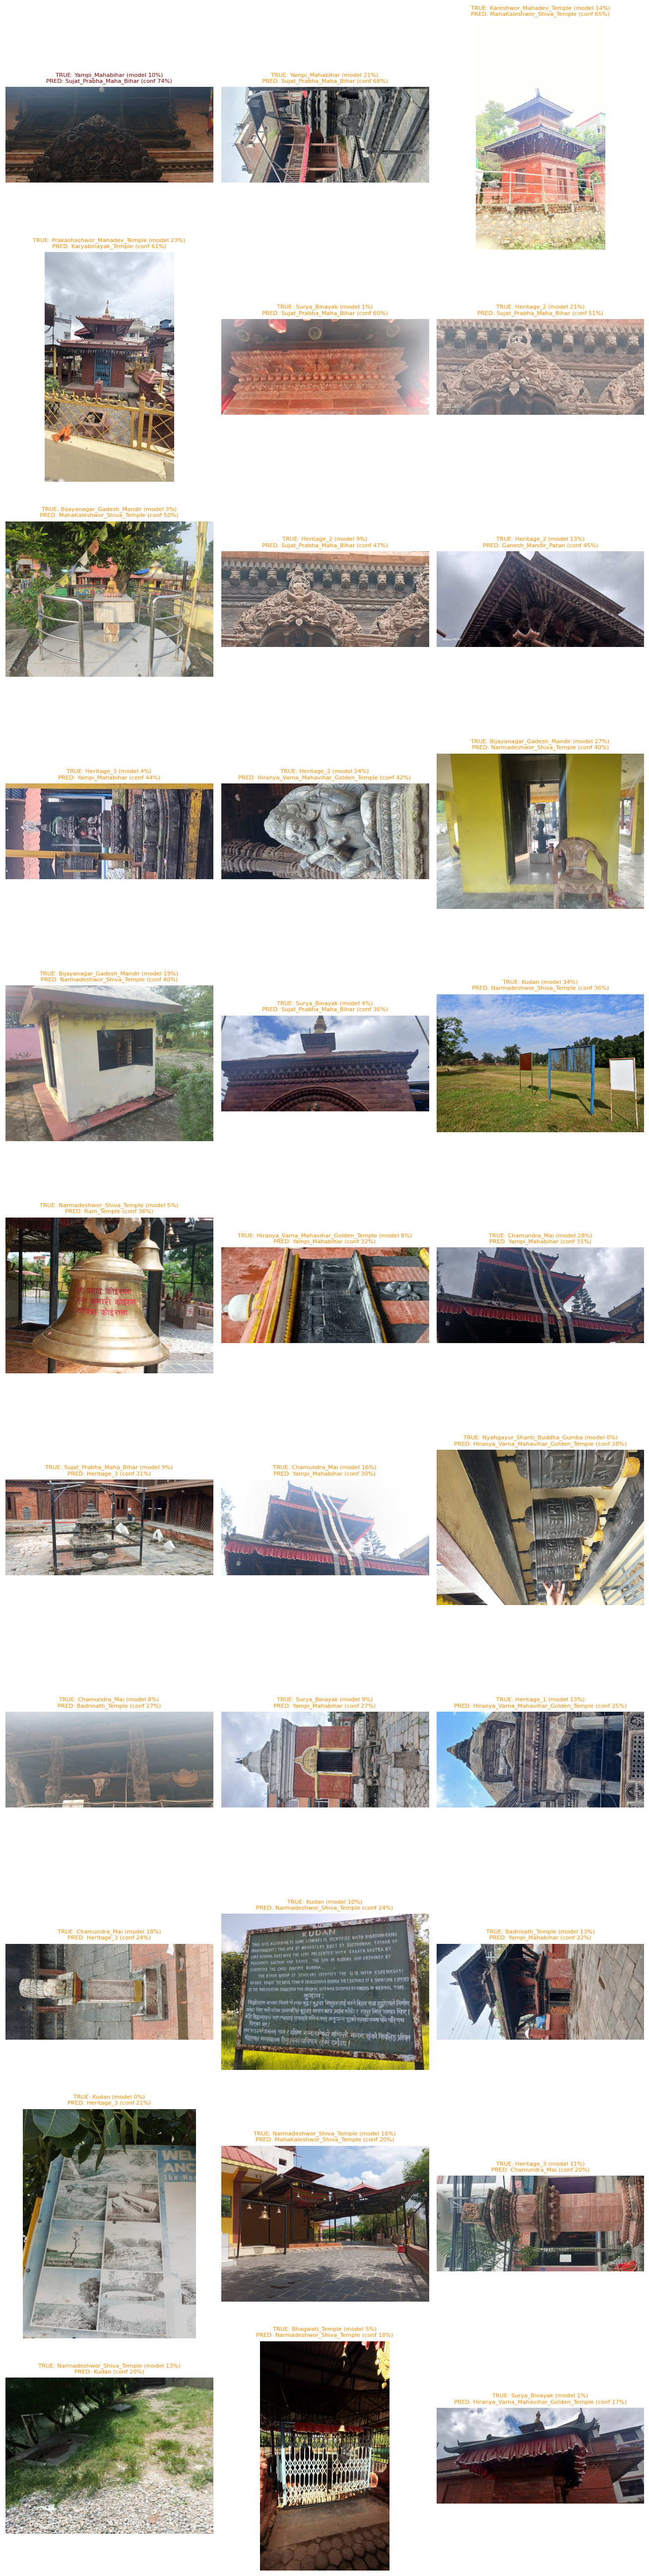

In [6]:
samples = dm.test_dataset.samples

def involved(t, p):
    return True if FOCUS is None else (classes[t] == FOCUS or classes[p] == FOCUS)

wrong = []
for (path, t), p, pc, tc in zip(samples, y_pred, pred_conf, true_conf):
    if t != p and involved(t, p):
        wrong.append((Path(path), t, p, pc, tc))
wrong.sort(key=lambda r: r[3], reverse=True)

title = f'FOCUS = {FOCUS}' if FOCUS else 'ALL classes'
print(f'{len(wrong)} misclassified images ({title})')
n_hi = sum(1 for r in wrong if r[3] > 0.7)
print(f'  of these, {n_hi} are HIGH-confidence (>70%) — inspect first')

if wrong:
    ncols = 3
    nrows = (len(wrong) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4.3*nrows), squeeze=False)
    axes = axes.reshape(-1)
    for ax in axes: ax.axis('off')
    for ax, (path, t, p, pc, tc) in zip(axes, wrong):
        ax.imshow(Image.open(path).convert('RGB'))
        colour = 'darkred' if pc > 0.7 else 'darkorange'
        ax.set_title(f'TRUE: {classes[t]} (model {tc:.0%})\n'
                     f'PRED: {classes[p]} (conf {pc:.0%})', fontsize=7.5, color=colour)
    plt.tight_layout(); plt.show()
else:
    print('No mistakes match the filter.')